In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [244]:
dataset = pd.read_csv("/content/drive/MyDrive/Career_Switch_Prediction_Dataset (1).csv")
dataset.head(10)
dataset.shape
display(dataset.head())


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


**Finding out how many null values are there in each features**

In [245]:
dataset.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,1113
relevent_experience,0
enrolled_university,107
education_level,118
major_discipline,724
experience,11
company_size,1571


**Checking if the dataset is balanced**

In [246]:
print(dataset["will_change_career"].value_counts())
print(dataset["will_change_career"].value_counts(normalize=True))  # percentage


will_change_career
0    3738
1    1262
Name: count, dtype: int64
will_change_career
0    0.7476
1    0.2524
Name: proportion, dtype: float64


**Features classification**

In [247]:
##Selecting numerical features
numerical_data = dataset.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)


There are 4 numerical features: 

['enrollee_id', 'city_development_index', 'training_hours', 'will_change_career']


In [248]:
#Selecting categoricalfeatures
categorical_data=dataset.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 10 categorical features: 

['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


In [249]:
# Transposed stats for numerical features

numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,5000.0,17022.88300,9656.969716,7.000,8736.500,17068.000,25389.25,33380.000
city_development_index,5000.0,0.82941,0.122429,0.448,0.743,0.903,0.92,0.949
training_hours,5000.0,65.02720,59.946693,1.000,23.000,47.000,88.00,336.000
will_change_career,5000.0,0.25240,0.434433,0.000,0.000,0.000,1.00,1.000


In [250]:
# Transposed stats for categorical features

categorical_data.describe().T

,count,unique,top,freq
city,5000,113,city_103,1163
gender,3887,3,Male,3507
relevent_experience,5000,2,Has relevent experience,3598
enrolled_university,4893,3,no_enrollment,3571
education_level,4882,5,Graduate,3037
major_discipline,4276,6,STEM,3786
experience,4989,22,>20,859
company_size,3429,8,50-99,813
company_type,3379,6,Pvt Ltd,2550
last_new_job,4896,6,1,2094


**Histogram of numerical data**

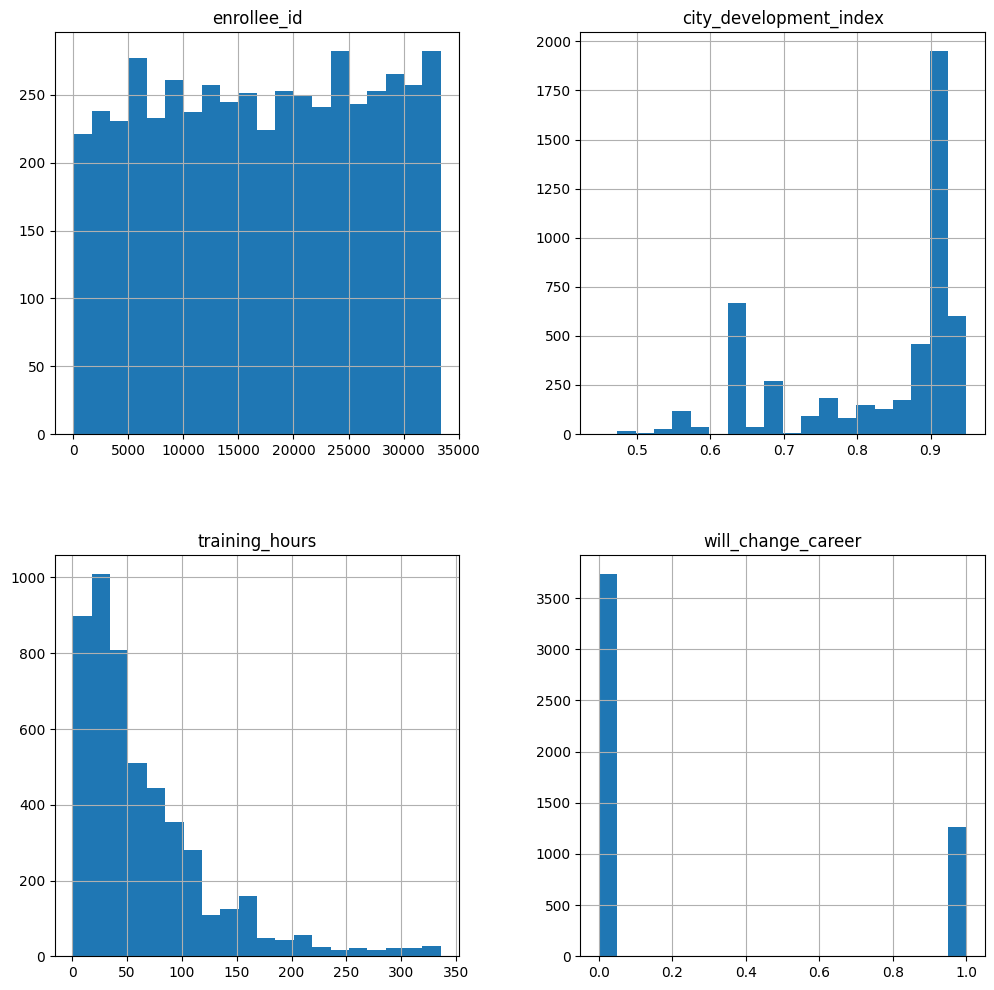

In [251]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

**Boxplot for numerical data**

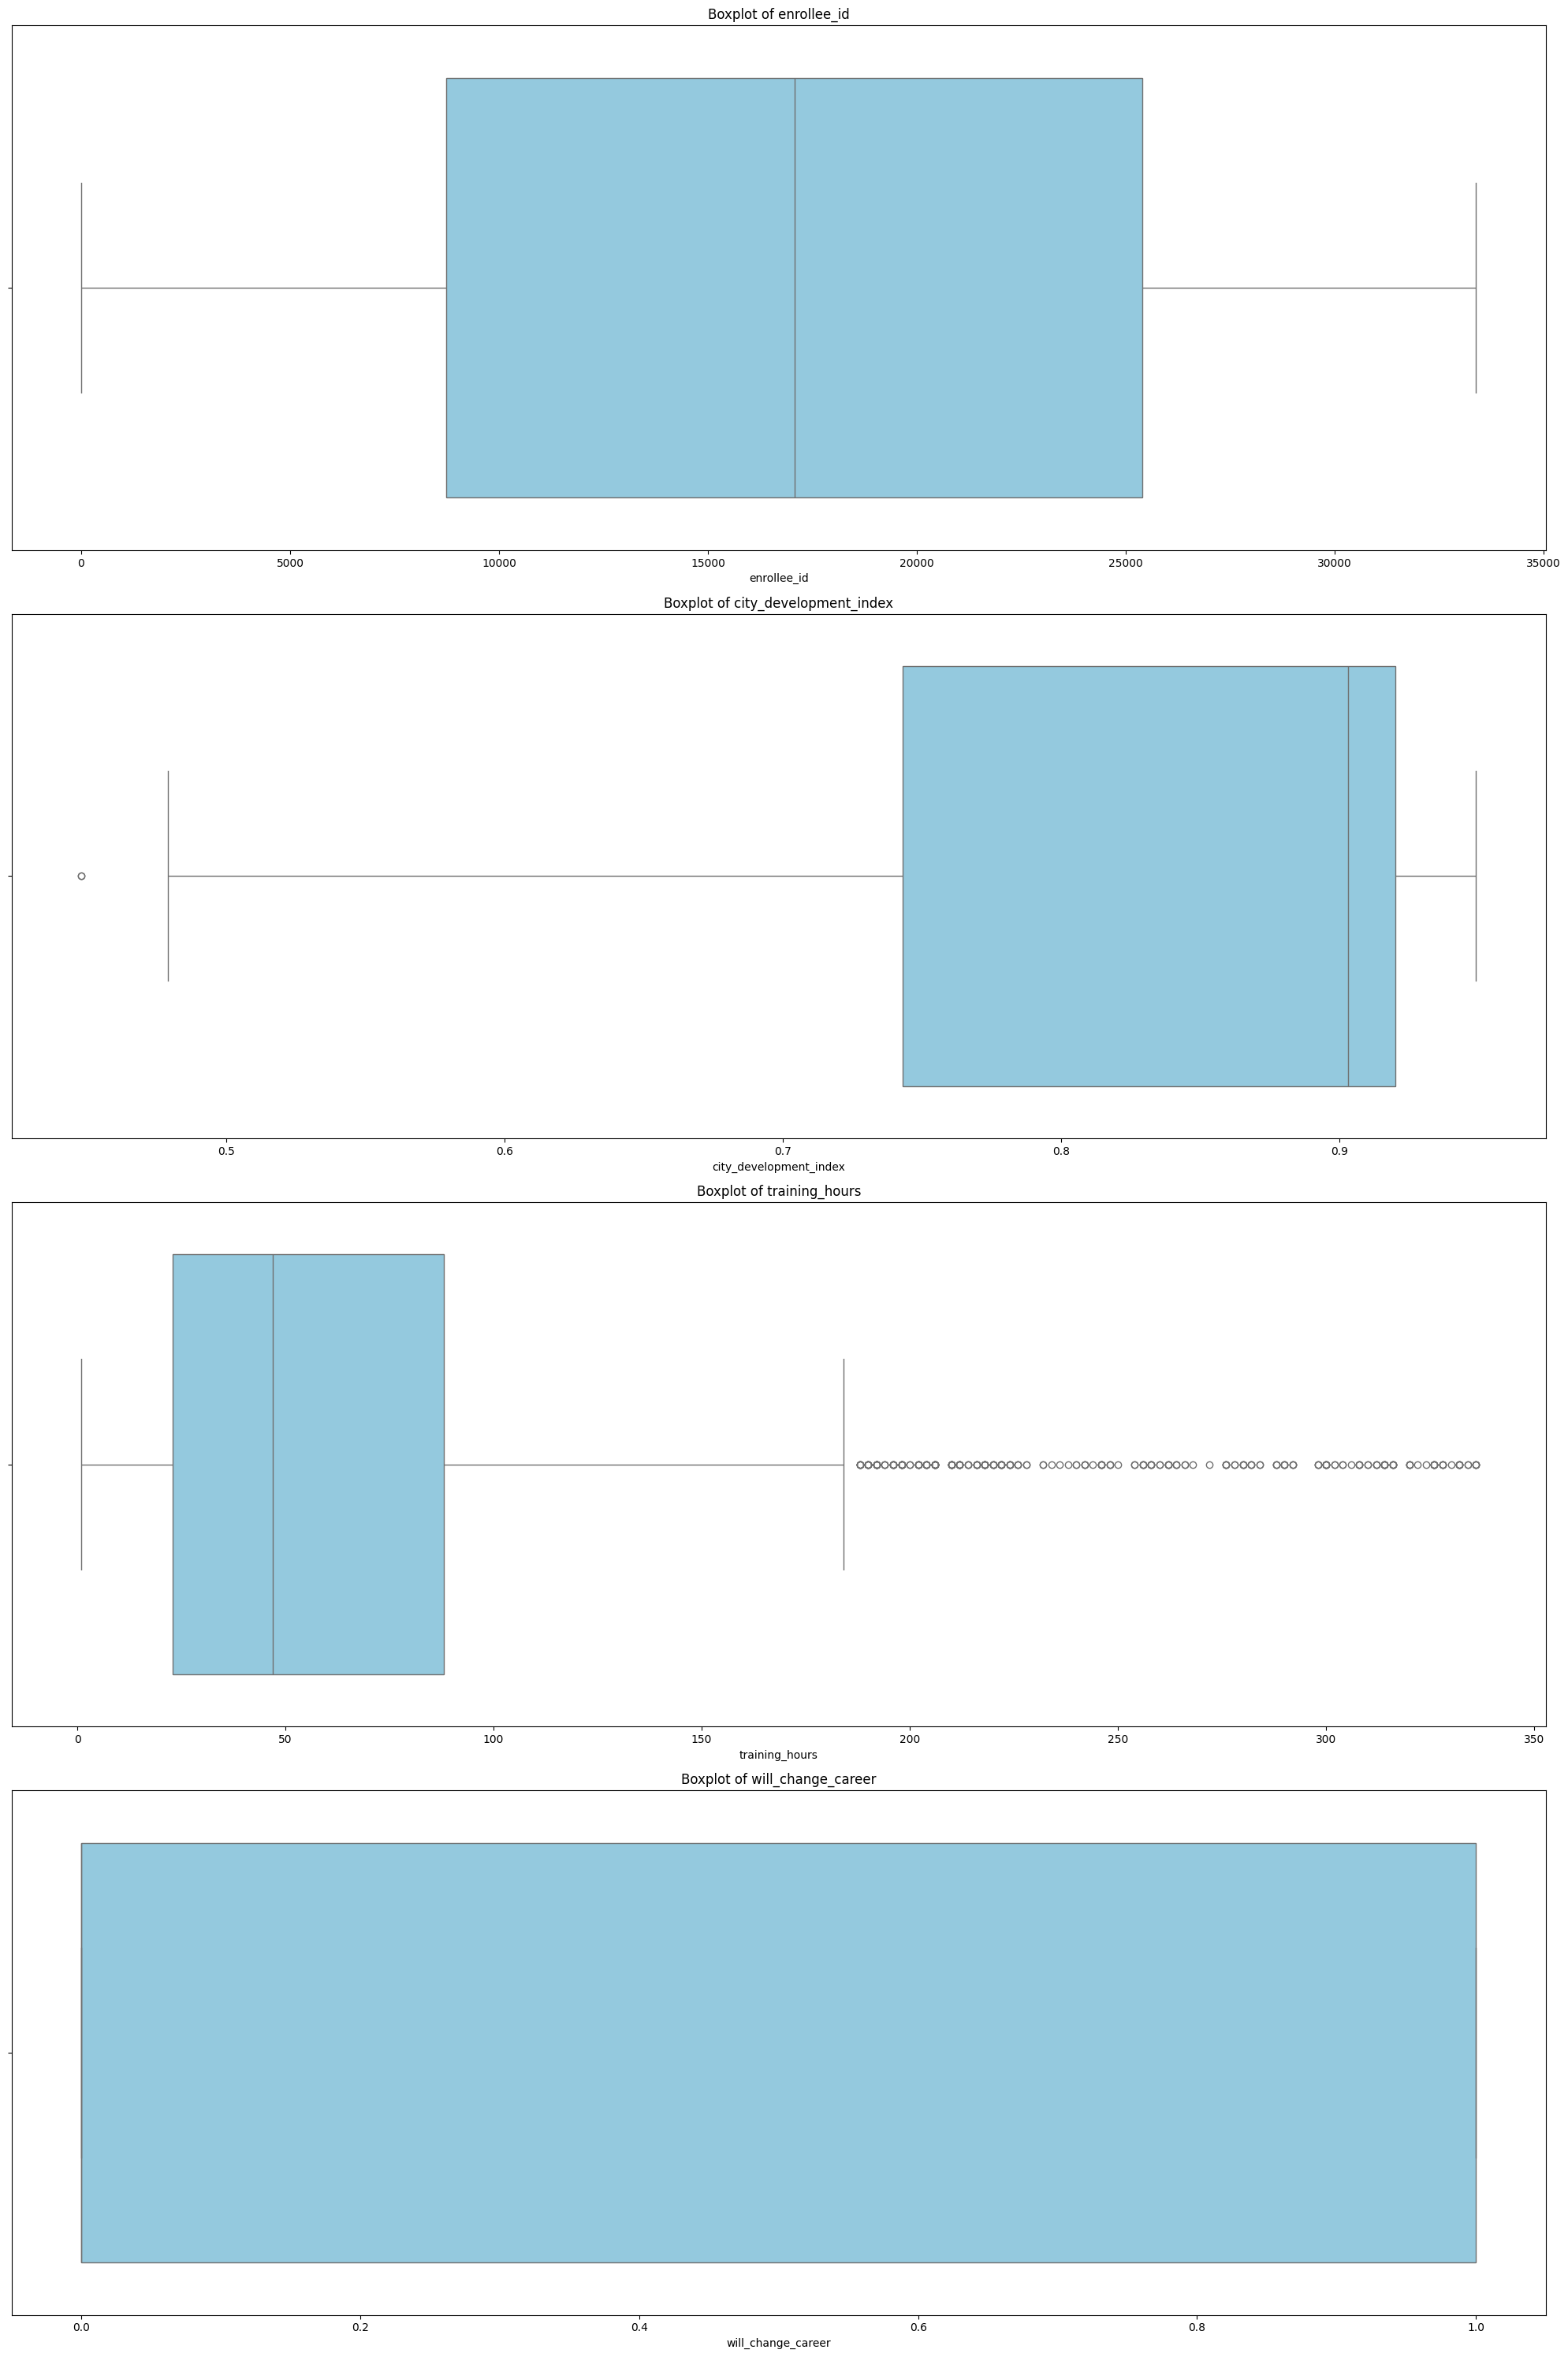

In [252]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'OUTCOME'
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

**Density plots of numerical features**

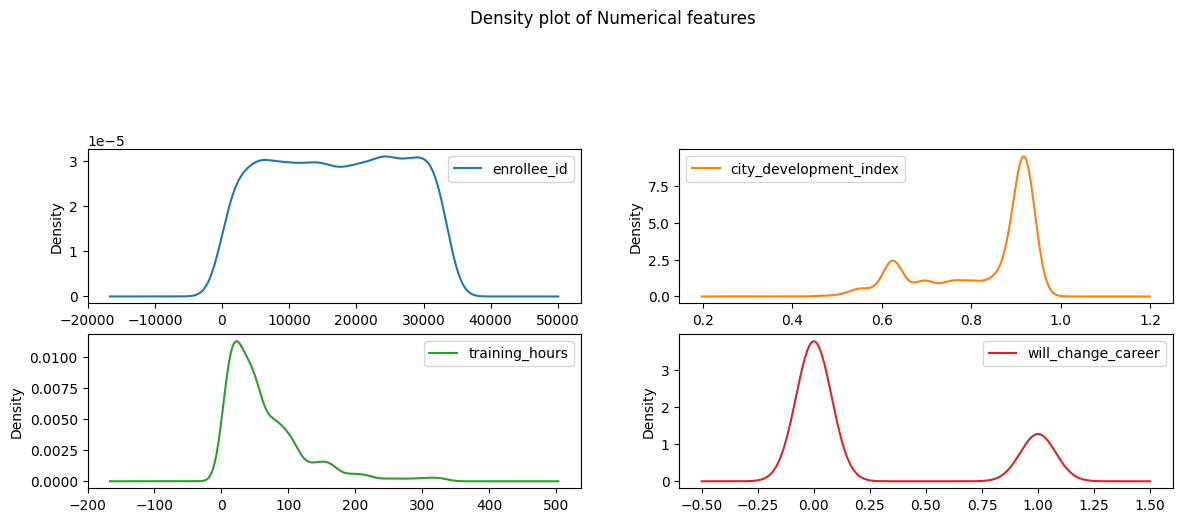

In [253]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

**Correlation for numerical features**

In [254]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
correlation_matrix

,enrollee_id,city_development_index,training_hours,will_change_career
enrollee_id,1.000000,-0.039610,-0.004381,0.049445
city_development_index,-0.039610,1.000000,0.004717,-0.346808
training_hours,-0.004381,0.004717,1.000000,-0.022170
will_change_career,0.049445,-0.346808,-0.022170,1.000000


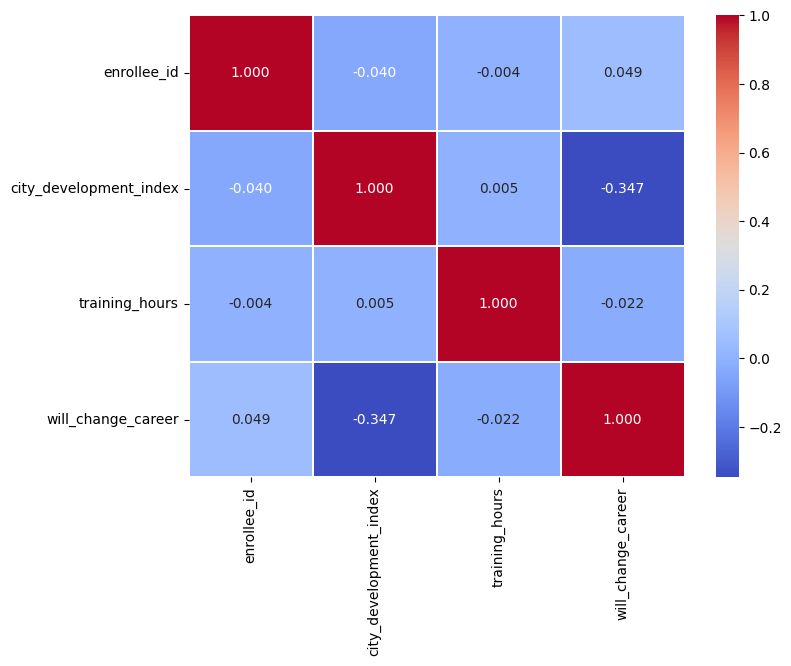

In [255]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

**Comparison of different correlation method for numerical features**

<Axes: title={'center': 'Kendall method'}>

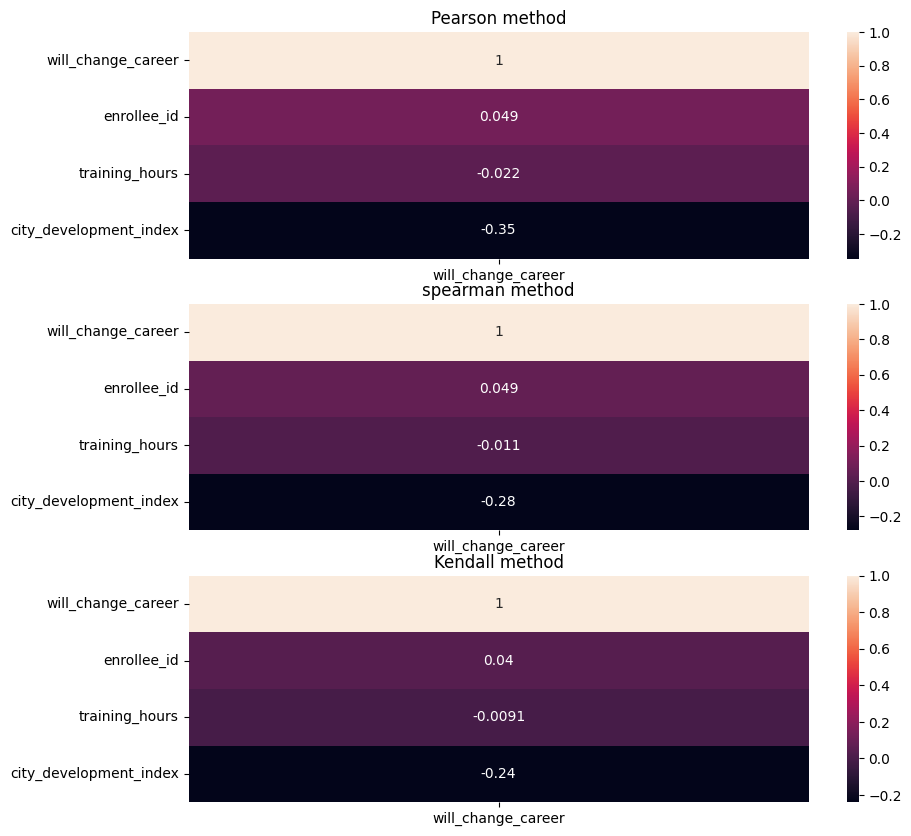

In [256]:
fig, ax = plt.subplots(3,1, figsize=(10, 10))
## Correlation coefficient using different methods
corr1 = numerical_data.corr('pearson')[['will_change_career']].sort_values(by='will_change_career', ascending=False)
corr2 = numerical_data.corr('spearman')[['will_change_career']].sort_values(by='will_change_career', ascending=False)
corr3 = numerical_data.corr('kendall')[['will_change_career']].sort_values(by='will_change_career', ascending=False)

#setting titles for each plot
ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')

## Generating heatmaps of each methods
sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

**Barplot of unique value counts in every categorical features**

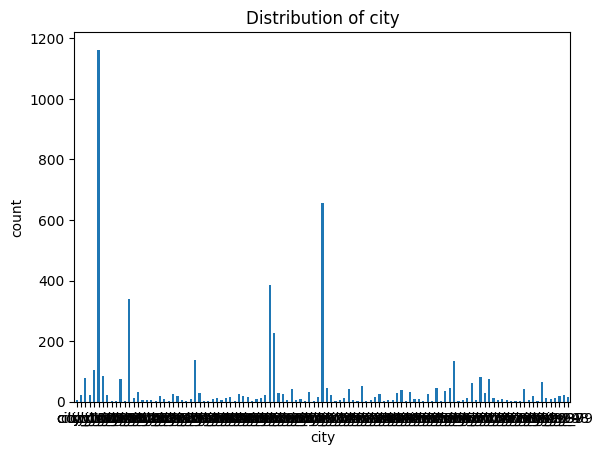

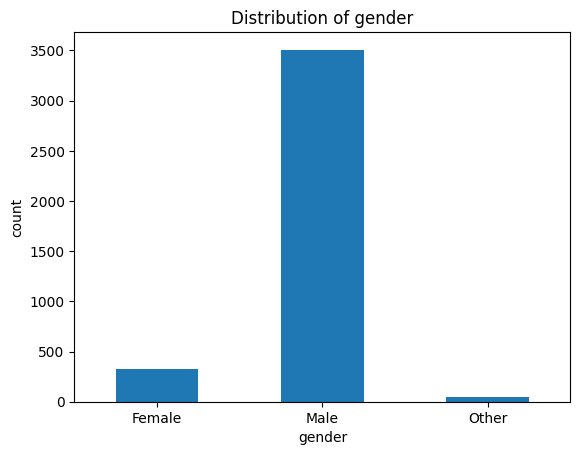

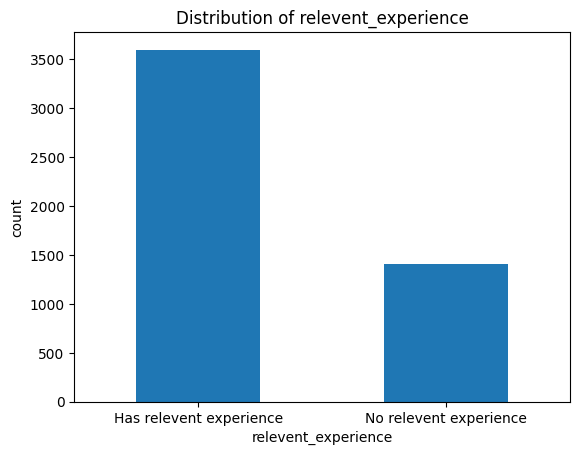

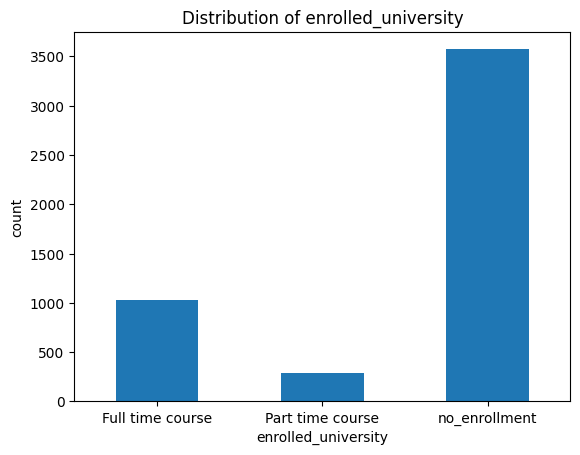

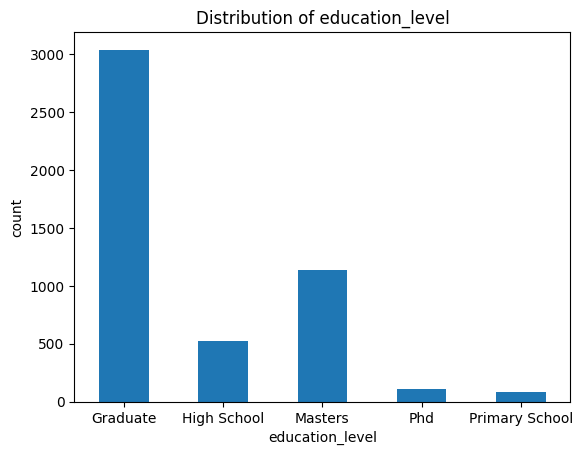

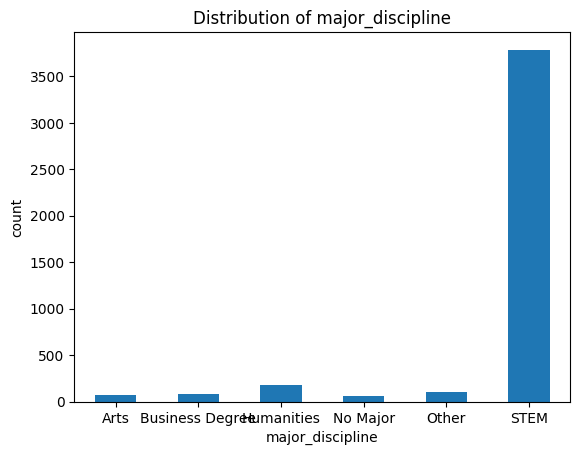

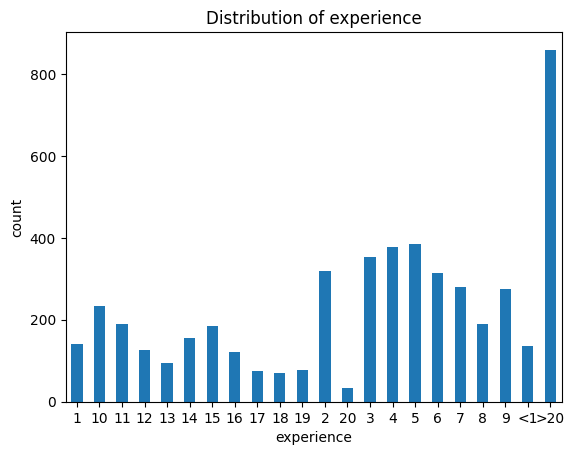

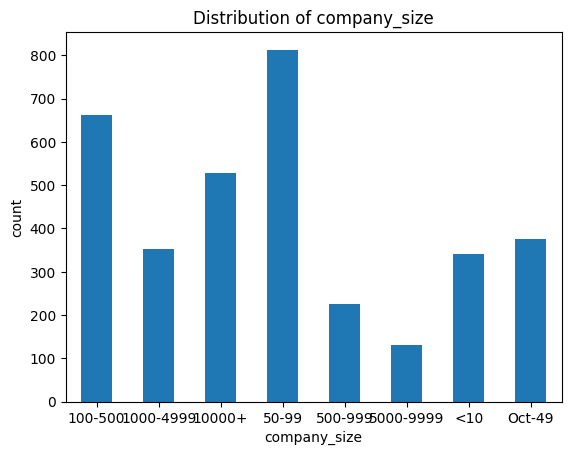

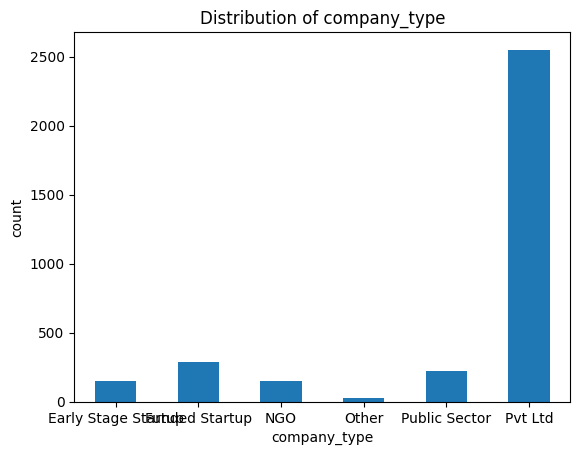

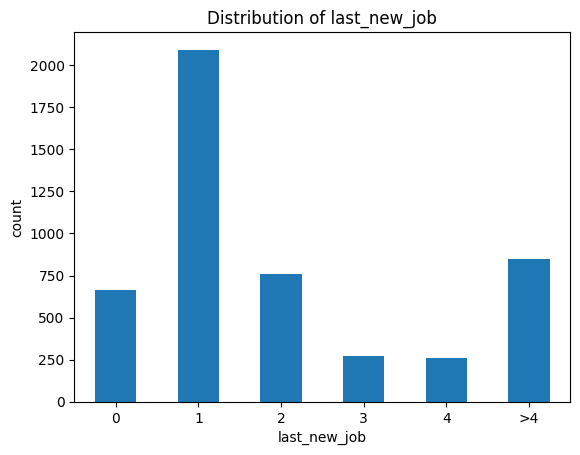

In [257]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

**Cramer's V for categorical features**

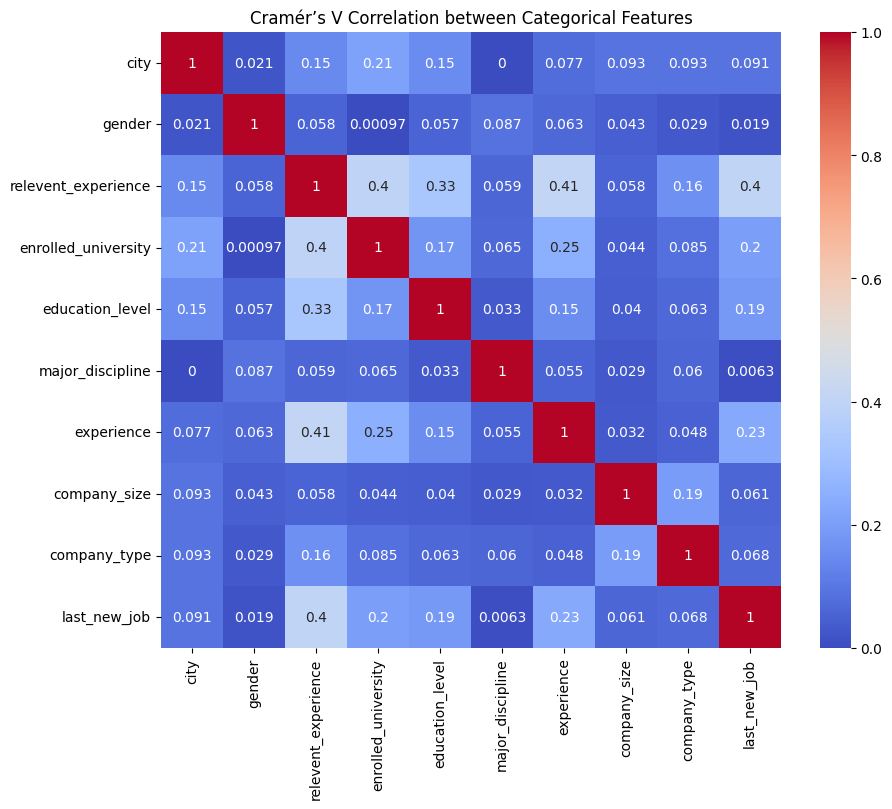

In [258]:
# Your categorical features
categorical_features = ['city', 'gender', 'relevent_experience', 'enrolled_university',
                        'education_level', 'major_discipline', 'experience',
                        'company_size', 'company_type', 'last_new_job']

# Function to calculate Cramér’s V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Create empty correlation matrix
cramers_results = pd.DataFrame(np.zeros((len(categorical_features), len(categorical_features))),
                               index=categorical_features,
                               columns=categorical_features)

# Fill the matrix
for f1 in categorical_features:
    for f2 in categorical_features:
        if f1 == f2:
            cramers_results.loc[f1, f2] = 1.0
        else:
            cramers_results.loc[f1, f2] = cramers_v(dataset[f1], dataset[f2])  # replace dataset with your DataFrame name

# Display heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cramers_results, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Cramér’s V Correlation between Categorical Features")
plt.show()


**Dropping Columns which dont have impact on target**

In [259]:
# Create a list of redundant column names to drop (including enrollee_id)
to_drop = ["enrollee_id", "city"]

# Drop those columns from the dataset (silently ignore any missing ones)
dataset_subset = dataset.drop(columns=to_drop, errors="ignore")

# Print out the head of the new dataset
dataset_subset.head()


,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


**Imputing numerical features with median valuee to handle NaNs**

In [260]:
from sklearn.impute import SimpleImputer

# Median imputation for your numeric features
impute = SimpleImputer(missing_values=np.nan, strategy='median')

num_cols = ["city_development_index", "training_hours"]

# Fit on the data (for EDA). For modeling, fit on TRAIN only, then transform test.
impute.fit(dataset_subset[num_cols])

dataset_subset[num_cols] = impute.transform(dataset_subset[num_cols])

In [261]:
dataset_subset

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36.0,1
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47.0,0
2,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83.0,0
3,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52.0,1
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.624,Female,Has relevent experience,no_enrollment,Graduate,STEM,3,100-500,NaN,1,114.0,1
4996,0.624,Male,No relevent experience,no_enrollment,Graduate,STEM,3,100-500,Pvt Ltd,1,64.0,1
4997,0.910,Male,No relevent experience,no_enrollment,High School,NaN,>20,5000-9999,Pvt Ltd,>4,89.0,0
4998,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,10,10000+,Pvt Ltd,>4,20.0,1


**No of unique values per feature**

In [262]:
# List of categorical columns
categorical_features = ['gender', 'relevent_experience', 'enrolled_university',
                        'education_level', 'major_discipline', 'experience',
                        'company_size', 'company_type', 'last_new_job']

# Display unique values for each column
for col in categorical_features:
    print(f"\nColumn: {col}")
    print(dataset_subset[col].unique())
    print(f"Number of unique values: {dataset_subset[col].nunique()}")



Column: gender
['Male' nan 'Female' 'Other']
Number of unique values: 3

Column: relevent_experience
['Has relevent experience' 'No relevent experience']
Number of unique values: 2

Column: enrolled_university
['no_enrollment' 'Full time course' nan 'Part time course']
Number of unique values: 3

Column: education_level
['Graduate' 'Masters' 'High School' nan 'Phd' 'Primary School']
Number of unique values: 5

Column: major_discipline
['STEM' 'Business Degree' nan 'Arts' 'Humanities' 'No Major' 'Other']
Number of unique values: 6

Column: experience
['>20' '15' '5' '<1' '11' '13' '7' '17' '2' '16' '1' '4' '10' '14' '18'
 '19' '12' '3' '6' '9' '8' '20' nan]
Number of unique values: 22

Column: company_size
[nan '50-99' '<10' '10000+' '5000-9999' '1000-4999' 'Oct-49' '100-500'
 '500-999']
Number of unique values: 8

Column: company_type
[nan 'Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Other'
 'Public Sector' 'NGO']
Number of unique values: 6

Column: last_new_job
['1' '>4' '0' '4'

**Imputing NaNs and mapping categorical features**

In [263]:
from sklearn.preprocessing import LabelEncoder

# Assuming dataset_subset is your dataframe
# Step 1: Define columns (added 'relevent_experience' to nominal features)
nominal_features = ['gender', 'enrolled_university', 'major_discipline', 'company_type', 'relevent_experience']
ordinal_features = ['education_level', 'experience', 'company_size', 'last_new_job']

# Step 2: Fill NaNs with "Unknown" for all categorical features
for col in nominal_features + ordinal_features:
    dataset_subset[col] = dataset_subset[col].fillna("Unknown")

# Step 3: Define custom mappings for ordinal features (include "Unknown")
education_order = {'Unknown': -1, 'Primary School': 0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd': 4}
experience_order = {'Unknown': -1, '<1': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6,
                    '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12, '13': 13,
                    '14': 14, '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, '>20': 21}
company_size_order = {'Unknown': -1, '<10': 0, 'Oct-49': 1, '50-99': 2, '100-500': 3, '500-999': 4,
                      '1000-4999': 5, '5000-9999': 6, '10000+': 7}
last_new_job_order = {'Unknown': -1, 'never': 0, '0':0, '1': 1, '2': 2, '3': 3, '4': 4, '>4': 5}

# Step 4: Apply mappings to ordinal features
dataset_subset['education_level'] = dataset_subset['education_level'].map(education_order)
dataset_subset['experience'] = dataset_subset['experience'].map(experience_order)
dataset_subset['company_size'] = dataset_subset['company_size'].map(company_size_order)
dataset_subset['last_new_job'] = dataset_subset['last_new_job'].map(last_new_job_order)

# Step 5: One-hot encode nominal features (including relevent_experience)
dataset_subset = pd.get_dummies(dataset_subset, columns=nominal_features, drop_first=True)

# Check result
dataset_subset.head()


,city_development_index,education_level,experience,company_size,last_new_job,training_hours,will_change_career,gender_Male,gender_Other,gender_Unknown,...,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown,relevent_experience_No relevent experience
0,0.920,2,21,-1,1,36.0,1,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,0.776,2,15,2,5,47.0,0,True,False,False,...,False,True,False,False,False,False,False,True,False,True
2,0.624,2,5,-1,0,83.0,0,False,False,True,...,False,True,False,False,False,False,False,False,True,True
3,0.789,2,0,-1,0,52.0,1,False,False,True,...,False,False,False,False,False,False,False,True,False,True
4,0.767,3,21,2,4,8.0,0,True,False,False,...,False,True,False,True,False,False,False,False,False,False


In [264]:
dataset_subset

,city_development_index,education_level,experience,company_size,last_new_job,training_hours,will_change_career,gender_Male,gender_Other,gender_Unknown,...,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown,relevent_experience_No relevent experience
0,0.920,2,21,-1,1,36.0,1,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,0.776,2,15,2,5,47.0,0,True,False,False,...,False,True,False,False,False,False,False,True,False,True
2,0.624,2,5,-1,0,83.0,0,False,False,True,...,False,True,False,False,False,False,False,False,True,True
3,0.789,2,0,-1,0,52.0,1,False,False,True,...,False,False,False,False,False,False,False,True,False,True
4,0.767,3,21,2,4,8.0,0,True,False,False,...,False,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.624,2,3,3,1,114.0,1,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4996,0.624,2,3,3,1,64.0,1,True,False,False,...,False,True,False,False,False,False,False,True,False,True
4997,0.910,1,21,6,5,89.0,0,True,False,False,...,False,False,True,False,False,False,False,True,False,True
4998,0.920,2,10,7,5,20.0,1,False,False,False,...,False,True,False,False,False,False,False,True,False,False


**Making True False value of Nominal Features to 0/1**

In [265]:
for col in dataset_subset.select_dtypes(include='bool').columns:
    dataset_subset[col] = dataset_subset[col].astype(int)

dataset_subset

,city_development_index,education_level,experience,company_size,last_new_job,training_hours,will_change_career,gender_Male,gender_Other,gender_Unknown,...,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown,relevent_experience_No relevent experience
0,0.920,2,21,-1,1,36.0,1,1,0,0,...,0,1,0,0,0,0,0,0,1,0
1,0.776,2,15,2,5,47.0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,1
2,0.624,2,5,-1,0,83.0,0,0,0,1,...,0,1,0,0,0,0,0,0,1,1
3,0.789,2,0,-1,0,52.0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,1
4,0.767,3,21,2,4,8.0,0,1,0,0,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.624,2,3,3,1,114.0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
4996,0.624,2,3,3,1,64.0,1,1,0,0,...,0,1,0,0,0,0,0,1,0,1
4997,0.910,1,21,6,5,89.0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,1
4998,0.920,2,10,7,5,20.0,1,0,0,0,...,0,1,0,0,0,0,0,1,0,0


**Applying scaling on all features ---> MinMaxScaler**

In [266]:
from sklearn.preprocessing import MinMaxScaler

# Select all columns except target
X = dataset_subset.drop(columns=['will_change_career'])
y = dataset_subset['will_change_career']

# Scale all features together using MinMaxScaler (scales values between 0 and 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame with same column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()


,city_development_index,education_level,experience,company_size,last_new_job,training_hours,gender_Male,gender_Other,gender_Unknown,enrolled_university_Part time course,...,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown,relevent_experience_No relevent experience
0,0.942116,0.6,1.000000,0.000,0.333333,0.104478,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.654691,0.6,0.727273,0.375,1.000000,0.137313,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.351297,0.6,0.272727,0.000,0.166667,0.244776,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.680639,0.6,0.045455,0.000,0.166667,0.152239,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.636727,0.8,1.000000,0.375,0.833333,0.020896,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


**Checking if any features have null values**

In [267]:
X_scaled.isnull().sum()

,0
city_development_index,0
education_level,0
experience,0
company_size,0
last_new_job,0
training_hours,0
gender_Male,0
gender_Other,0
gender_Unknown,0
enrolled_university_Part time course,0


**Correlation Between all the features after scaling**

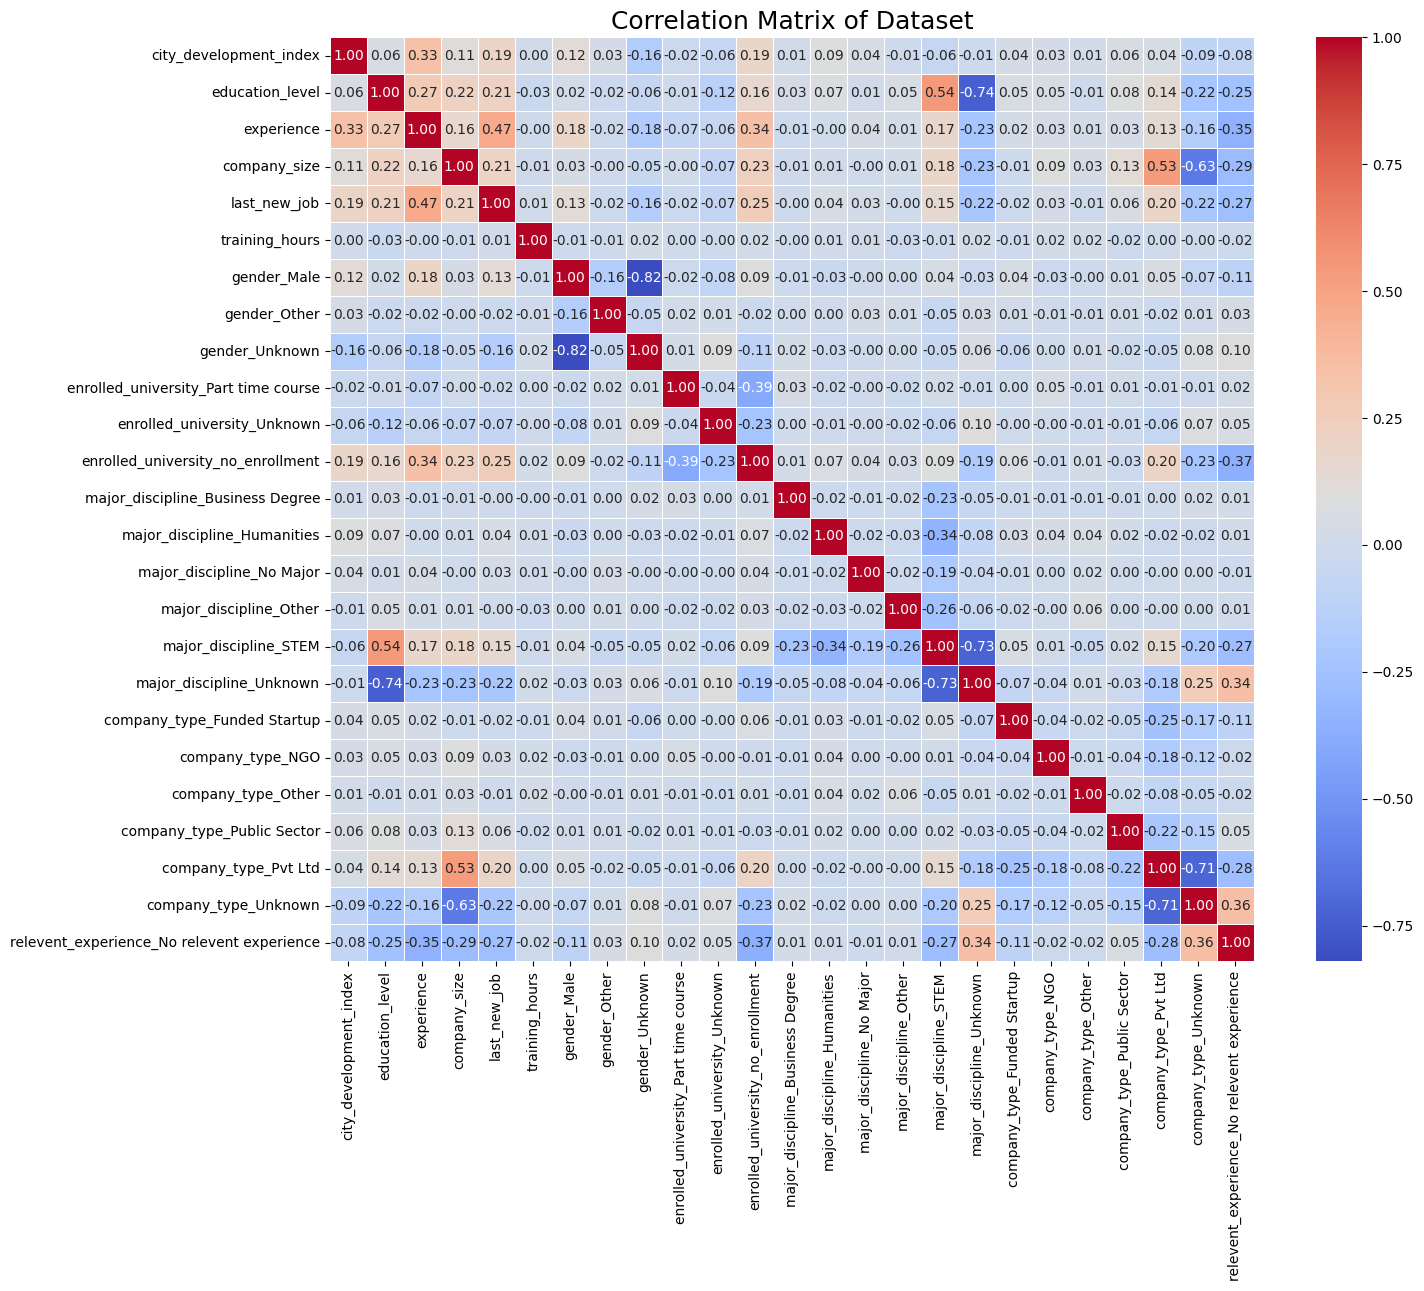

In [268]:

# Compute correlation matrix
corr_matrix = X_scaled.corr()

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap
sns.heatmap(corr_matrix,
            annot=True,       # show correlation values
            fmt=".2f",        # format
            cmap="coolwarm",  # color map
            cbar=True,
            square=True,
            linewidths=0.5)

plt.title("Correlation Matrix of Dataset", fontsize=18)
plt.show()


**Finding Highly correlated features after scaling to drop.**

In [269]:
import numpy as np

# Compute correlation matrix
corr_matrix = X_scaled.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print("Highly correlated columns to consider dropping:", to_drop)

# Didn't drop gender_unknown to help Model predict


Highly correlated columns to consider dropping: ['gender_Unknown']


In [270]:
X_scaled

,city_development_index,education_level,experience,company_size,last_new_job,training_hours,gender_Male,gender_Other,gender_Unknown,enrolled_university_Part time course,...,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown,relevent_experience_No relevent experience
0,0.942116,0.6,1.000000,0.000,0.333333,0.104478,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.654691,0.6,0.727273,0.375,1.000000,0.137313,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.351297,0.6,0.272727,0.000,0.166667,0.244776,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.680639,0.6,0.045455,0.000,0.166667,0.152239,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.636727,0.8,1.000000,0.375,0.833333,0.020896,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.351297,0.6,0.181818,0.500,0.333333,0.337313,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4996,0.351297,0.6,0.181818,0.500,0.333333,0.188060,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4997,0.922156,0.4,1.000000,0.875,1.000000,0.262687,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4998,0.942116,0.6,0.500000,1.000,1.000000,0.056716,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Scaling again to prevent data leakage so that the model dont memorise.**

In [271]:
# 1. Split the data first (stratified)
from sklearn.model_selection import train_test_split

X = X_scaled
y = dataset_subset['will_change_career']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# 2. Scale numeric columns
num_cols = ['city_development_index', 'training_hours', 'education_level', 'experience', 'company_size', 'last_new_job']

scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])  # fit on train only
X_test[num_cols] = scaler.transform(X_test[num_cols])        # use same scaler on test

# Now X_train and X_test are scaled safely


**Oversampling to balance the train data**

In [272]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Check original class distribution
print("Original train class distribution:", Counter(y_train))

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Oversample the training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Balanced train class distribution:", Counter(y_train_balanced))


Original train class distribution: Counter({0: 2803, 1: 947})
Balanced train class distribution: Counter({0: 2803, 1: 2803})


**Intializing a dictionary to keep the information of every model report to use them to compare models**

In [273]:
results = {
    "Logistic Regression": {},
    "Naive Bayes": {},
    "Neural Network": {}}

**Modeled using Logistic Regression**

In [274]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,classification_report, confusion_matrix, roc_auc_score)

# -----------------------------
# Logistic Regression Model
# -----------------------------
log_reg = LogisticRegression(solver='liblinear', random_state=42)
log_reg.fit(X_train_balanced, y_train_balanced)

# Predictions & Probabilities
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

# Store all required information in results
results["Logistic Regression"] = {
    "y_pred": y_pred_lr,                        # predicted class labels
    "y_prob": y_prob_lr,                        # predicted probabilities (for ROC/AUC)
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "auc": roc_auc_score(y_test, y_prob_lr),
    "confusion_matrix": confusion_matrix(y_test, y_pred_lr),
    "classification_report": classification_report(y_test, y_pred_lr, output_dict=True)
}


# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Accuracy: 0.724

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.73      0.80       935
           1       0.47      0.71      0.56       315

    accuracy                           0.72      1250
   macro avg       0.68      0.72      0.68      1250
weighted avg       0.78      0.72      0.74      1250


Confusion Matrix:
 [[681 254]
 [ 91 224]]


**Modeled using Naive Bayes**

In [275]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score
)

# -----------------------------
# Naive Bayes Model
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train_balanced, y_train_balanced)

# Predictions & Probabilities
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]  # needed for ROC/AUC

# Store all required information in results
results["Naive Bayes"] = {
    "y_pred": y_pred_nb,
    "y_prob": y_prob_nb,
    "accuracy": accuracy_score(y_test, y_pred_nb),
    "precision": precision_score(y_test, y_pred_nb),
    "recall": recall_score(y_test, y_pred_nb),
    "auc": roc_auc_score(y_test, y_prob_nb),
    "confusion_matrix": confusion_matrix(y_test, y_pred_nb),
    "classification_report": classification_report(y_test, y_pred_nb, output_dict=True)
}


# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


Accuracy: 0.6072

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.56      0.68       935
           1       0.36      0.74      0.49       315

    accuracy                           0.61      1250
   macro avg       0.61      0.65      0.58      1250
weighted avg       0.74      0.61      0.63      1250


Confusion Matrix:
 [[527 408]
 [ 83 232]]


**Modeled using Neural Netwoks**

In [276]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score
)

# -----------------------------
# Neural Network Model
# -----------------------------
tf.random.set_seed(42)

# Build the model
nn_model = Sequential([
    Dense(64, input_dim=X_train_balanced.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model
nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = nn_model.fit(
    X_train_balanced, y_train_balanced,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# Predictions & Probabilities
y_prob_nn = nn_model.predict(X_test).ravel()  # flatten to 1D array
y_pred_nn = (y_prob_nn > 0.5).astype(int)

# Store all required information in results
results["Neural Network"] = {
    "y_pred": y_pred_nn,
    "y_prob": y_prob_nn,
    "accuracy": accuracy_score(y_test, y_pred_nn),
    "precision": precision_score(y_test, y_pred_nn),
    "recall": recall_score(y_test, y_pred_nn),
    "auc": roc_auc_score(y_test, y_prob_nn),
    "confusion_matrix": confusion_matrix(y_test, y_pred_nn),
    "classification_report": classification_report(y_test, y_pred_nn, output_dict=True)
}

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6329 - loss: 0.6378 - val_accuracy: 0.3984 - val_loss: 0.8062
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6925 - loss: 0.5821 - val_accuracy: 0.4866 - val_loss: 0.7895
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7154 - loss: 0.5534 - val_accuracy: 0.5766 - val_loss: 0.7561
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7346 - loss: 0.5361 - val_accuracy: 0.6506 - val_loss: 0.7283
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7413 - loss: 0.5302 - val_accuracy: 0.6898 - val_loss: 0.6919
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7500 - loss: 0.5242 - val_accuracy: 0.6845 - val_loss: 0.7055
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7622 - loss: 0.5099 - val_accuracy: 0.7130 - val_loss: 0.6603
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7618 - loss: 0.5137 - val_accuracy: 0.7201 - val_

**Model Comparison analysis**

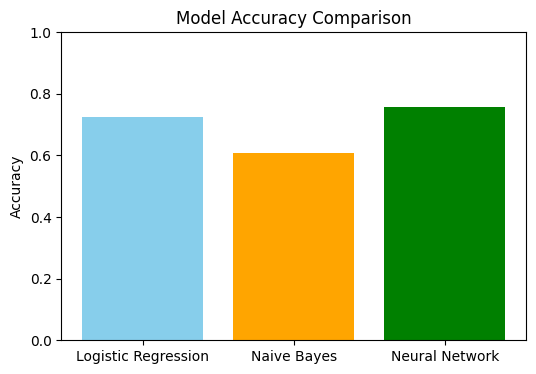

In [277]:
#Bar chart for accuracy
import matplotlib.pyplot as plt

# Extract accuracy for each model
accuracies = {model: results[model]["accuracy"] for model in results}

plt.figure(figsize=(6,4))
plt.bar(accuracies.keys(), accuracies.values(), color=['skyblue', 'orange', 'green'])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()


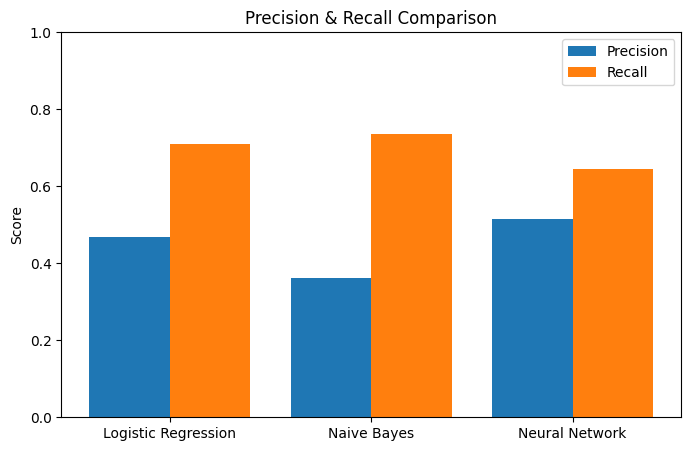

In [278]:
#Bar Chart for Precision & Recall

precisions = {model: results[model]["precision"] for model in results}
recalls = {model: results[model]["recall"] for model in results}

x = range(len(results))

plt.figure(figsize=(8,5))
plt.bar(x, precisions.values(), width=0.4, label="Precision", align='center')
plt.bar([i+0.4 for i in x], recalls.values(), width=0.4, label="Recall", align='center')

plt.xticks([i+0.2 for i in x], results.keys())
plt.ylabel("Score")
plt.title("Precision & Recall Comparison")
plt.ylim(0, 1)
plt.legend()
plt.show()


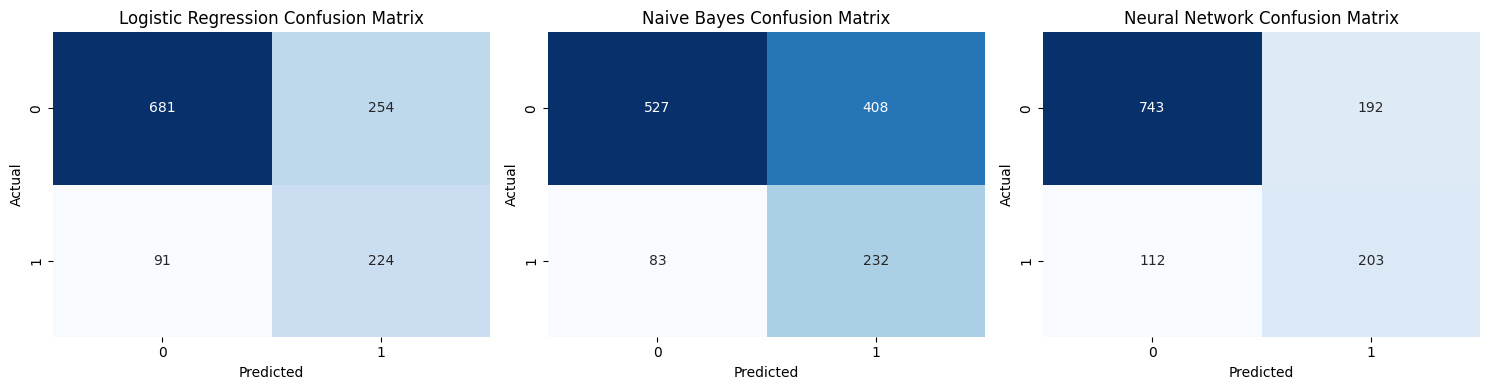

In [279]:
#Confusion Matrices for Each Model
import seaborn as sns
import numpy as np

plt.figure(figsize=(15,4))

for i, model in enumerate(results.keys()):
    cm = results[model]["confusion_matrix"]
    plt.subplot(1, len(results), i+1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()


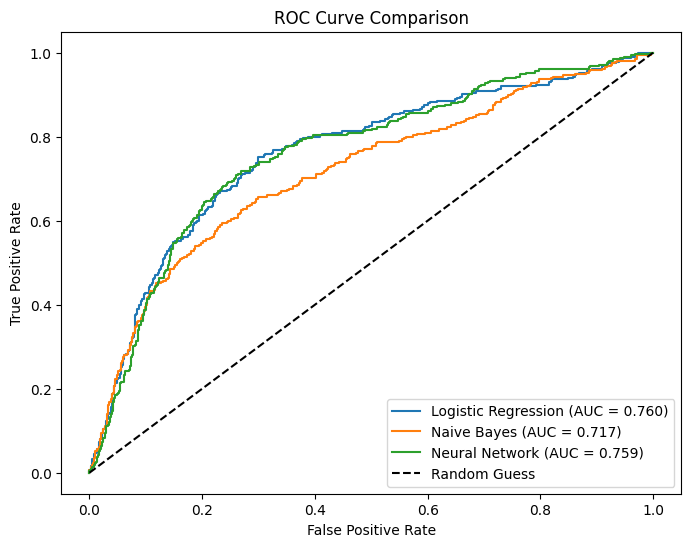

In [280]:
#ROC Curve + AUC for Each Model
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for model in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[model]["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

**Unsupervised Learning using K-means clustering**

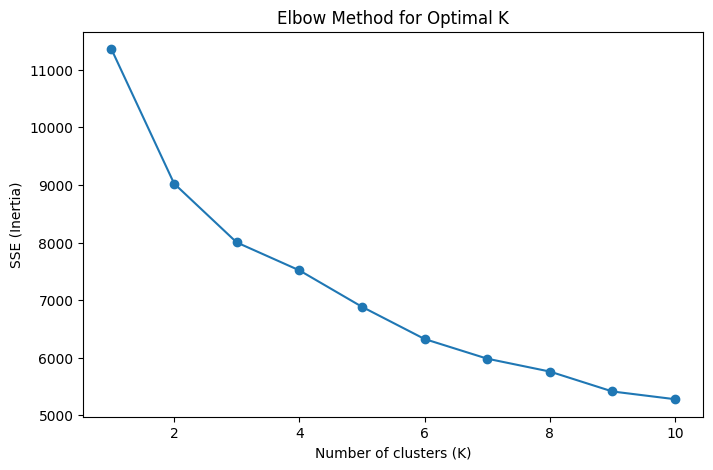

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


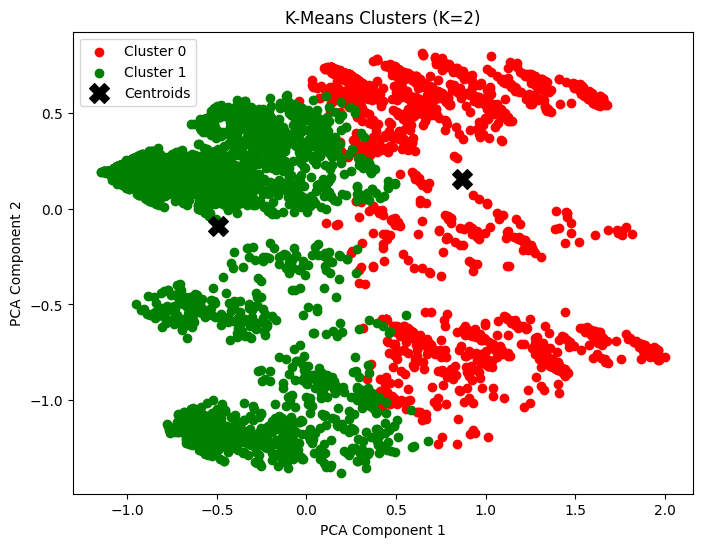

In [281]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# -----------------------------
# Step 1: Determine optimal K (Elbow Method)
# -----------------------------
sse = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.show()

# -----------------------------
# Step 2: Fit KMeans with chosen K
# -----------------------------
optimal_k = 2  # Replace with the K you choose from Elbow
km = KMeans(n_clusters=optimal_k, random_state=42)
clusters = km.fit_predict(X_scaled)

# Create a DataFrame to store cluster labels
df_clusters = pd.DataFrame(X_scaled, columns=X_scaled.columns)
df_clusters['Cluster'] = clusters

# -----------------------------
# Step 3: PCA for 2D visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
colors = ['red','green','blue','purple','orange','cyan']
for i in range(optimal_k):
    plt.scatter(X_pca[clusters==i, 0], X_pca[clusters==i, 1], color=colors[i], label=f'Cluster {i}')

# Transform centroids into PCA space
centroids_pca = pca.transform(km.cluster_centers_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], color='black', s=200, marker='X', label='Centroids')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"K-Means Clusters (K={optimal_k})")
plt.legend()
plt.show()

# -----------------------------
# Step 4: Inspect cluster centers
# -----------------------------
cluster_centers = pd.DataFrame(km.cluster_centers_, columns=X_scaled.columns)
# print("Cluster Centers:")
# print(cluster_centers)
